---
title: "Comparison of LDSC slopes vs intercepts of neuropsychiatric traits"
author: "Saikat Banerjee"
format:
  html: default
date: "2026-06-10"
file-modified: "2026-06-10"
abstract: "This notebook looks at the design of the input. 
It compares the sample overlap with genetic correlation."

---

## Background

If the intercept matrix and the slope matrix from LD score regression
are themselves collinear across trait pairs, 
then "NNM tracks intercept, NNM-Corr tracks slope" is untestable, 
because the two targets aren't separable. 

Moreover, $A^{-1}$ is built from the intercepts, 
so wherever sampling and genetic structure coincide, 
NNM-Corr is actively down-weighting directions that carry *real* genetic signal.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pymir import mpl_stylesheet
from pymir import mpl_utils
mpl_stylesheet.banskt_presentation(splinecolor='black', dpi=300, colors='kelly')

from matplotlib import colormaps as mpl_cmaps
import matplotlib.colors as mpl_colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
def normalize_trait_name(name):
    rename_map = {
        "Saxena": "Daytime_sleepiness",
    }
    if not isinstance(name, str):
        return name
    name = name.replace("-", "_")
    name = rename_map.get(name, name)
    return str(name)
    

def get_matrix_df_from_json(fpath, check_sanity=True):
    with open(Path(fpath), "r") as f:
        d = json.load(f)
    rows = []
    traits = []
    for a_vs_b, val in d.items():
        trait_a, trait_b = ([normalize_trait_name(x) for x in a_vs_b.split("_vs_")])
        traits.append(trait_a)
        traits.append(trait_b)
        rows.append({
            "trait_a": trait_a,
            "trait_b": trait_b,
            "rg": val,
        })
    traits = sorted(list(set(traits)))
    df = pd.DataFrame(rows)

    n = len(traits)
    R = pd.DataFrame(np.nan, index=traits, columns=traits, dtype=float)
    R.values[R.index.get_indexer(df["trait_a"]),
             R.columns.get_indexer(df["trait_b"])] = df["rg"].to_numpy()
    R.values[R.index.get_indexer(df["trait_b"]),
             R.columns.get_indexer(df["trait_a"])] = df["rg"].to_numpy()

    if check_sanity:
        # Max and min values
        print(f"max={R.max().max():.3g}, min={R.min().min():.3g}")
        # Symmetry sanity (in case the input accidentally contains BOTH directions)
        asym = np.nanmax(np.abs(R.values - R.values.T))
        print(f"max |R - R.T| = {asym:.3g}")   # expect 0.0 if each pair listed once
        
        # Coverage: how many off-diagonal pairs are actually populated?
        off = ~np.eye(len(traits), dtype=bool)
        print(f"populated off-diagonal fraction: {np.isfinite(R.values[off]).mean():.3f}")
        
    return R

## Read data

Also do some basic sanity check.

In [3]:
data_root="/gpfs/commons/home/sbanerjee/pgc/input"

R    = get_matrix_df_from_json(Path(data_root) / "ldsc_results/rg.txt")
R_se = get_matrix_df_from_json(Path(data_root) / "ldsc_results/rg_se.txt")
R_p  = get_matrix_df_from_json(Path(data_root) / "ldsc_results/rg_p.txt")

G    = get_matrix_df_from_json(Path(data_root) / "ldsc_results/gencov.txt")
G_se = get_matrix_df_from_json(Path(data_root) / "ldsc_results/gencov_se.txt")

S    = get_matrix_df_from_json(Path(data_root) / "ldsc_results/gcov_int.txt")
S_se = get_matrix_df_from_json(Path(data_root) / "ldsc_results/gcov_int_se.txt")

np.fill_diagonal(R.values, 1.0)

traits_meta_file = Path(data_root) / "trait_metadata.json"
with open(traits_meta_file , "r") as f:
    traits_meta = json.load(f)

max=3.87, min=-0.893
max |R - R.T| = 0
populated off-diagonal fraction: 0.949
max=10.8, min=0.00195
max |R - R.T| = 0
populated off-diagonal fraction: 0.949
max=0.999, min=0
max |R - R.T| = 0
populated off-diagonal fraction: 0.949
max=0.235, min=-0.104
max |R - R.T| = 0
populated off-diagonal fraction: 0.951
max=0.0508, min=0.0005
max |R - R.T| = 0
populated off-diagonal fraction: 0.951
max=1.4, min=-0.674
max |R - R.T| = 0
populated off-diagonal fraction: 0.951
max=0.0872, min=0.00397
max |R - R.T| = 0
populated off-diagonal fraction: 0.951


## Plotting function and Spearman correlation to compare

Use Spearman correlation instead of Pearson correlation
because we want to compare the rankings, 
not the absolute magnitudes.

In [4]:
from scipy.stats import spearmanr, pearsonr

def make_heatmap_figure(A, B, title_A="", title_B=""):
    
    def get_mpl_norm(X):
        ok = np.isfinite(X)
        vmin = np.quantile(X[ok], 0.1)
        vmax = np.quantile(X[ok], 0.95)
        vcenter = np.quantile(X[ok], 0.75)
        return mpl_colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
        
    
    A = A.to_numpy()
    B = B.to_numpy()
    
    fig = plt.figure(figsize = (16,8))
    gs  = fig.add_gridspec(nrows=1, ncols=2, wspace=0.4, hspace=0)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    cmap1 = mpl_cmaps.get_cmap("YlOrRd").copy()

    im1 = ax1.imshow(A, cmap=cmap1, norm=get_mpl_norm(A), origin='lower')
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size="5%", pad=0.2)
    cbar = plt.colorbar(im1, cax=cax, fraction=0.1)
    ax1.set_title(title_A, pad=20)

    im2 = ax2.imshow(B, cmap=cmap1, norm=get_mpl_norm(B), origin='lower')
    divider = make_axes_locatable(ax2)
    cax = divider.append_axes("right", size="5%", pad=0.2)
    cbar = plt.colorbar(im2, cax=cax, fraction=0.1)
    ax2.set_title(title_B, pad=20)

    plt.show()

    
def offdiag_check(S, G, R, P, n_perm=10000, seed=0,thr=0.05):
    """
    S = bivariate intercept (sampling covariance)
    G = bivariate slope (genetic covariance)
    Off-diagonals only
    """
    S = np.asarray(S, float)
    G = np.asarray(G, float)
    R = np.asarray(R, float)
    P = np.asarray(P, float)
    iu = np.triu_indices_from(S, k=1)
    x, y, rg, rg_p = np.abs(S[iu]), G[iu], R[iu], P[iu]
    ok = np.isfinite(x) & np.isfinite(y) & np.isfinite(rg)
    x, y, rg, rg_p = x[ok], y[ok], rg[ok], rg_p[ok]
    r_obs = spearmanr(x, y).statistic       # rank -> robust to the two different scales


    for lo, hi in [(0, .05), (.05, .1), (.1, .2), (.2, .4), (.4, 2.01)]:
        m = (np.abs(x) >= lo) & (np.abs(x) < hi)
        if m.sum() > 5:
            # print(f"|Sampling Covariance| ∈ [{lo},{hi}):\tn={m.sum():5d}  ")
            print(f"|Sampling Covariance| ∈ [{lo:.2f},{hi:.2f})"
                  f"\n\tn = {m.sum():5d}"
                  f"\n\tρ = {spearmanr(x[m], y[m]).statistic:+.3f}"
                  f"\n\tmedian|rg| = {np.median(np.abs(rg[m])):.3f}"
                  f"\n\t95th|rg| = {np.quantile(np.abs(rg[m]),.95):.3f}"
                  f"\n\tfrac_sig = {np.mean(rg_p[m]<thr):.3f}")

    rng = np.random.default_rng(seed); n = S.shape[0]; null = np.empty(n_perm)
    for b in range(n_perm):
        p = rng.permutation(n)
        null[b] = spearmanr(S[np.ix_(p, p)][iu][ok], y).statistic
    p = (np.sum(np.abs(null) >= abs(r_obs)) + 1) / (n_perm + 1)
    
    return dict(spearman=r_obs, pearson=pearsonr(x, y)[0], mantel_p=p, x=x, y=y)

def load_zscore(zscore_path):
    df = pd.read_csv(Path(zscore_path), header=0, index_col=0, dtype={0: str})
    df.index = df.index.map(str)
    df.columns = df.columns.map(str)
    return df

## 107 traits

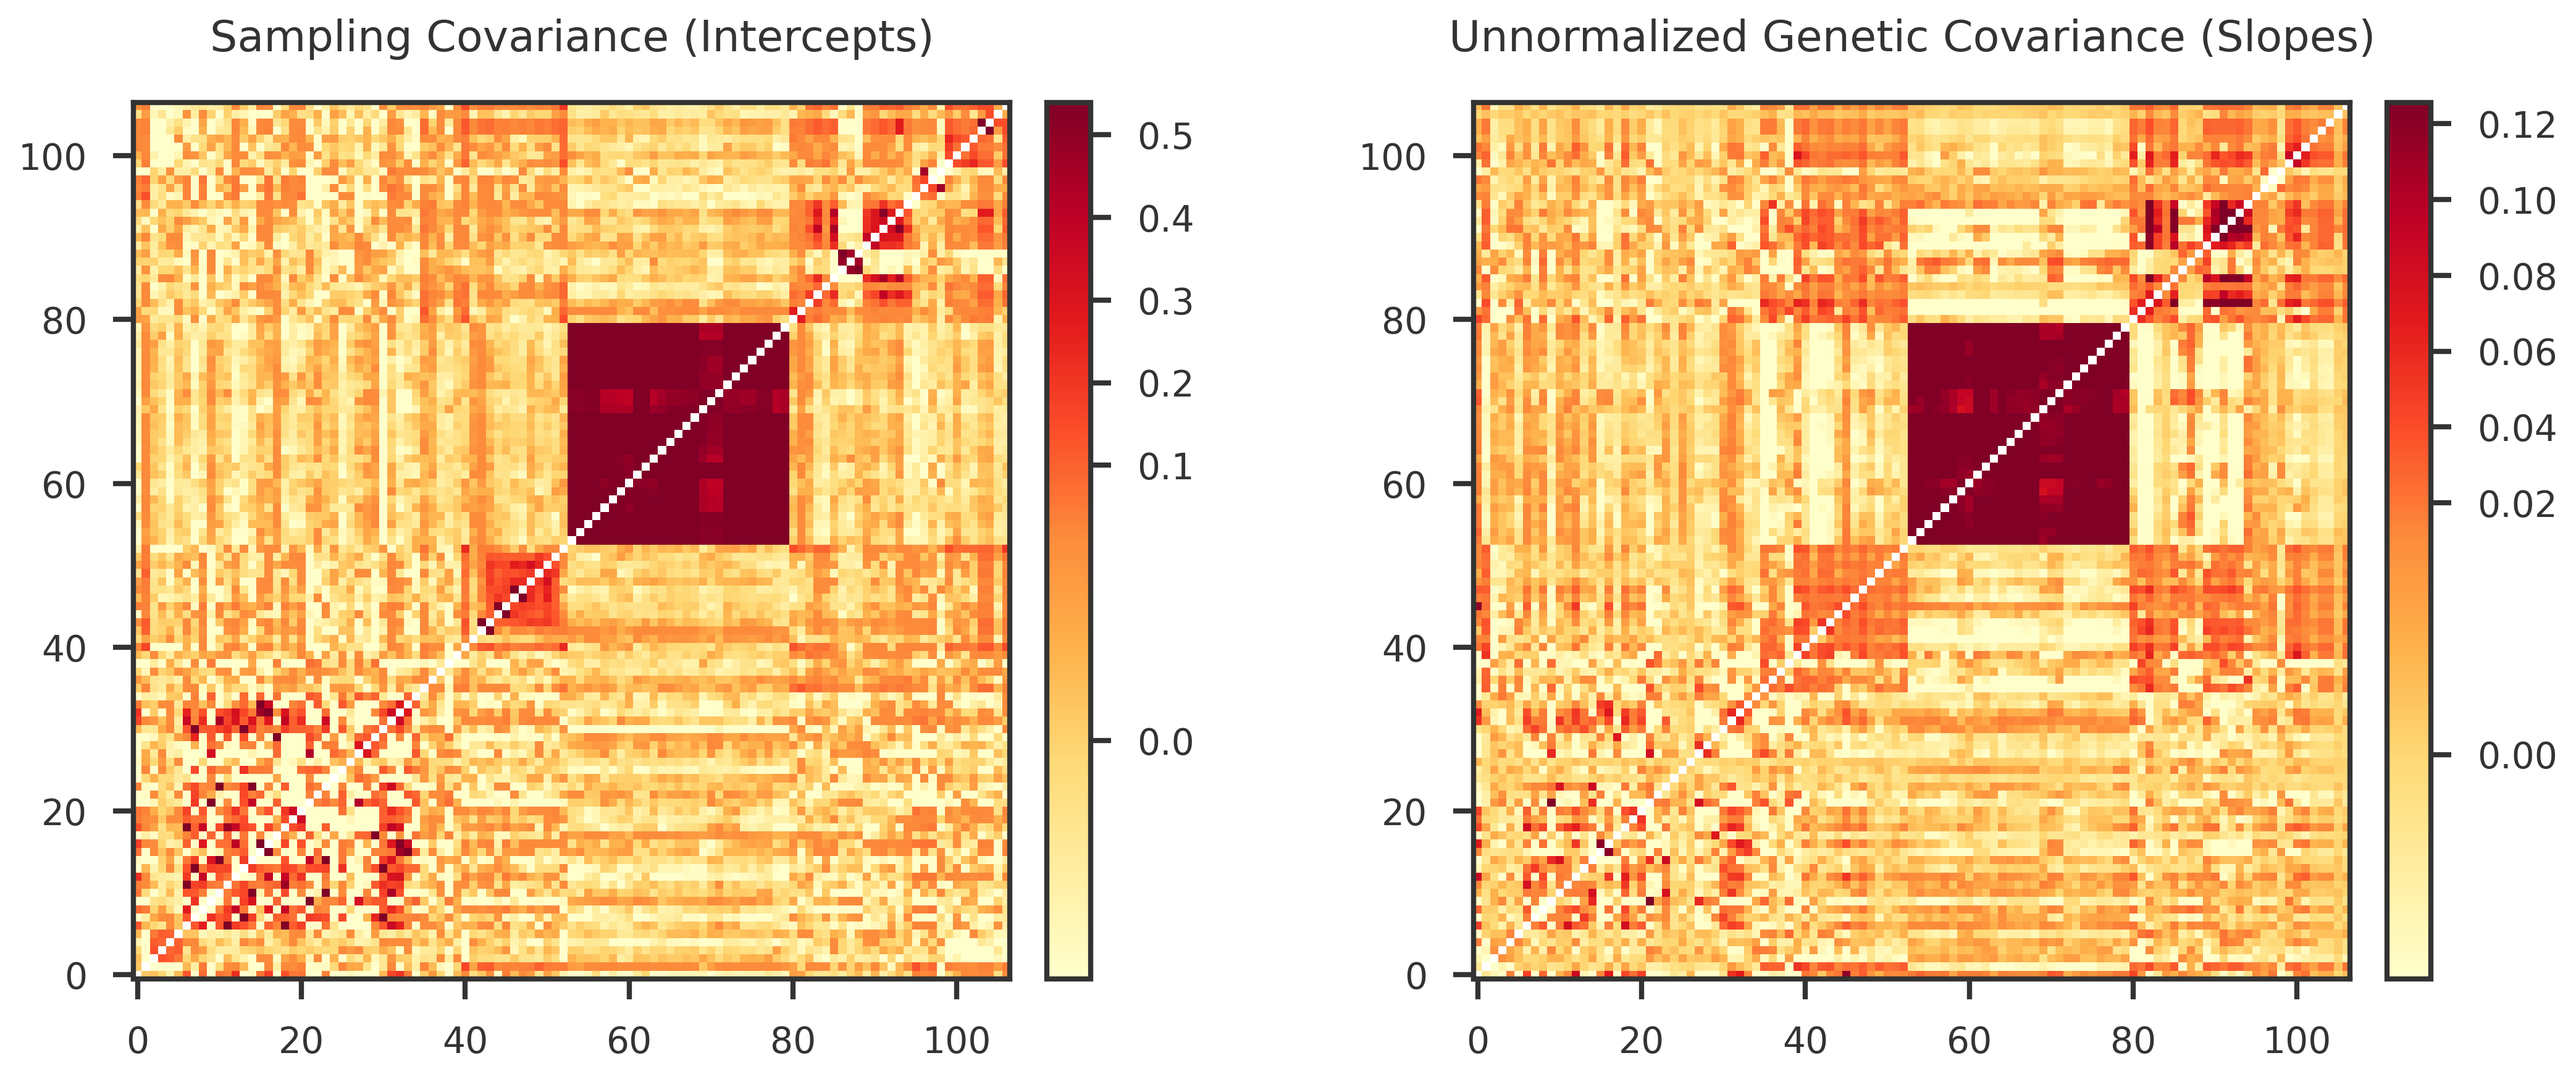

|Sampling Covariance| ∈ [0.00,0.05)
	n =  4841
	ρ = +0.103
	median|rg| = 0.063
	95th|rg| = 0.373
	frac_sig = 0.276
|Sampling Covariance| ∈ [0.05,0.10)
	n =   193
	ρ = +0.095
	median|rg| = 0.150
	95th|rg| = 0.771
	frac_sig = 0.782
|Sampling Covariance| ∈ [0.10,0.20)
	n =   169
	ρ = +0.119
	median|rg| = 0.224
	95th|rg| = 0.767
	frac_sig = 0.870
|Sampling Covariance| ∈ [0.20,0.40)
	n =    87
	ρ = +0.269
	median|rg| = 0.367
	95th|rg| = 1.111
	frac_sig = 0.989
|Sampling Covariance| ∈ [0.40,2.01)
	n =   381
	ρ = +0.825
	median|rg| = 0.804
	95th|rg| = 0.961
	frac_sig = 0.995


{'spearman': 0.3260796871672002,
 'pearson': 0.8993361068681653,
 'mantel_p': 9.999000099990002e-05,
 'x': array([0.001368  , 0.00216529, 0.0007015 , ..., 0.14691438, 0.14256507,
        0.00458009]),
 'y': array([-0.0037, -0.0076, -0.0311, ...,  0.0032,  0.014 ,  0.0025])}

In [5]:
Z = load_zscore(Path(data_root) / "pgc_v1.0/zscore_v1_0.csv")
trait_names = list(Z.index)

common_trait_names = sorted(
    trait_names,
    key=lambda trait: traits_meta[trait]['group']
)

S_107, G_107, R_107, R_p_107, S_se_107, G_se_107, R_se_107 = [
    df.loc[common_trait_names, common_trait_names]
    for df in (S, G, R, R_p, S_se, G_se, R_se)
]

make_heatmap_figure(
    S_107, G_107, 
    title_A="Sampling Covariance (Intercepts)", 
    title_B="Unnormalized Genetic Covariance (Slopes)")
offdiag_check(S_107, G_107, R_107, R_p_107)

## 78 traits

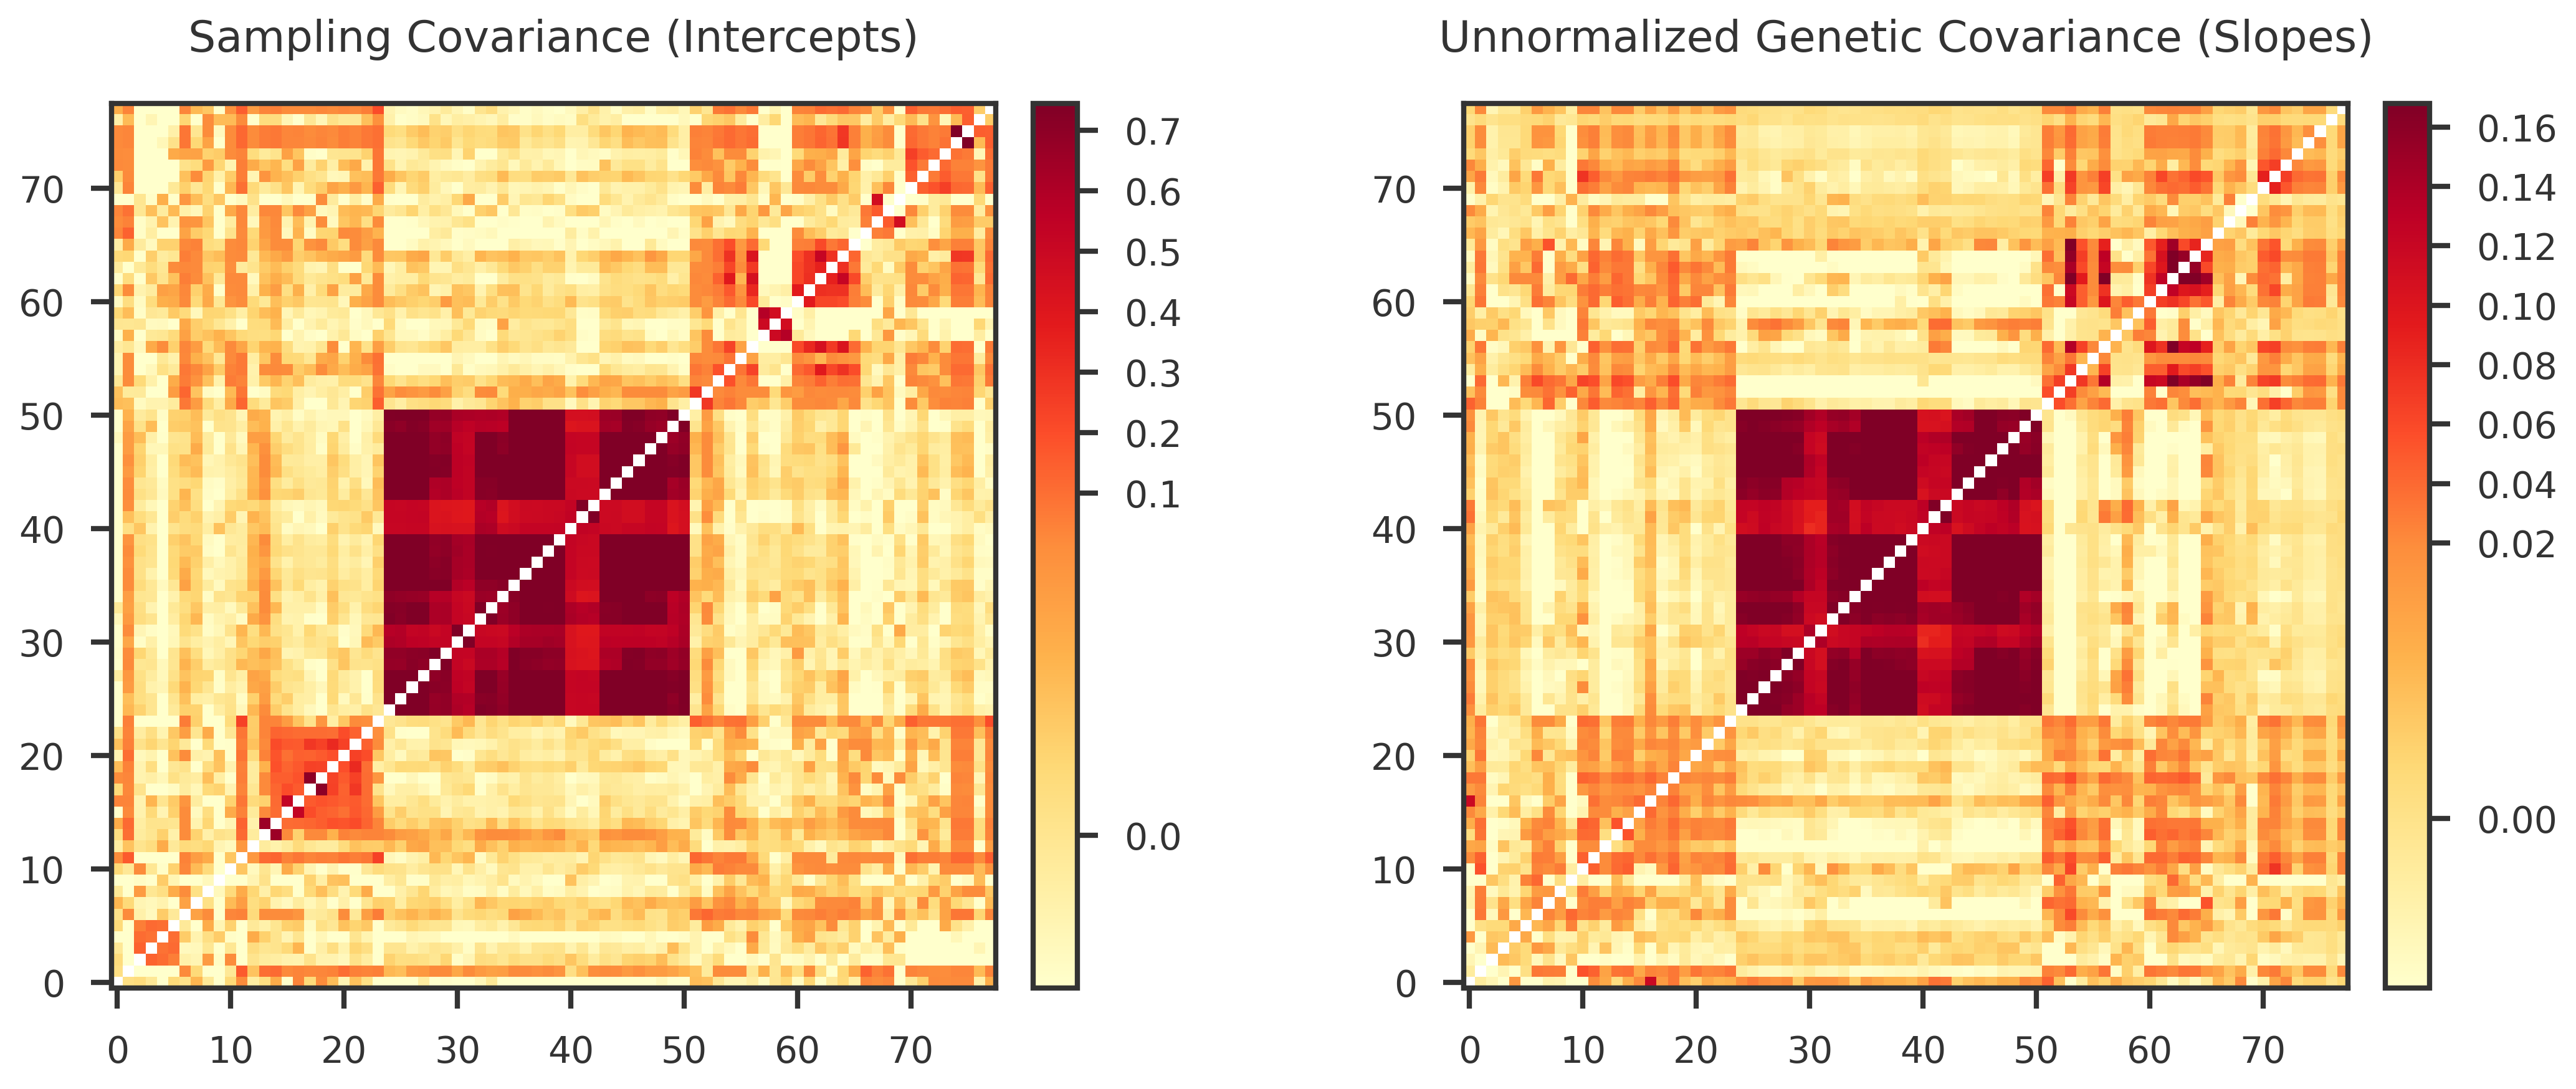

|Sampling Covariance| ∈ [0.00,0.05)
	n =  2453
	ρ = +0.183
	median|rg| = 0.087
	95th|rg| = 0.482
	frac_sig = 0.307
|Sampling Covariance| ∈ [0.05,0.10)
	n =    86
	ρ = +0.006
	median|rg| = 0.515
	95th|rg| = 0.854
	frac_sig = 0.977
|Sampling Covariance| ∈ [0.10,0.20)
	n =    70
	ρ = +0.088
	median|rg| = 0.538
	95th|rg| = 0.850
	frac_sig = 0.943
|Sampling Covariance| ∈ [0.20,0.40)
	n =    33
	ρ = +0.411
	median|rg| = 0.754
	95th|rg| = 1.196
	frac_sig = 1.000
|Sampling Covariance| ∈ [0.40,2.01)
	n =   361
	ρ = +0.903
	median|rg| = 0.807
	95th|rg| = 0.961
	frac_sig = 0.994


{'spearman': 0.5188576637631885,
 'pearson': 0.9415594245932899,
 'mantel_p': 9.999000099990002e-05,
 'x': array([0.001368  , 0.00216529, 0.0007015 , ..., 0.14691438, 0.14256507,
        0.00458009]),
 'y': array([-0.0037, -0.0076, -0.0311, ...,  0.0032,  0.014 ,  0.0025])}

In [6]:
Z = load_zscore(Path(data_root) / "pgc_v1.1/zscore_v1_1.csv")
trait_names = list(Z.index)

common_trait_names = sorted(
    trait_names,
    key=lambda trait: traits_meta[trait]['group']
)

S_78, G_78, R_78, R_p_78, S_se_78, G_se_78, R_se_78 = [
    df.loc[common_trait_names, common_trait_names]
    for df in (S, G, R, R_p, S_se, G_se, R_se)
]

make_heatmap_figure(
    S_78, G_78, 
    title_A="Sampling Covariance (Intercepts)", 
    title_B="Unnormalized Genetic Covariance (Slopes)")
offdiag_check(S_78, G_78, R_78, R_p_78)

## 51 traits

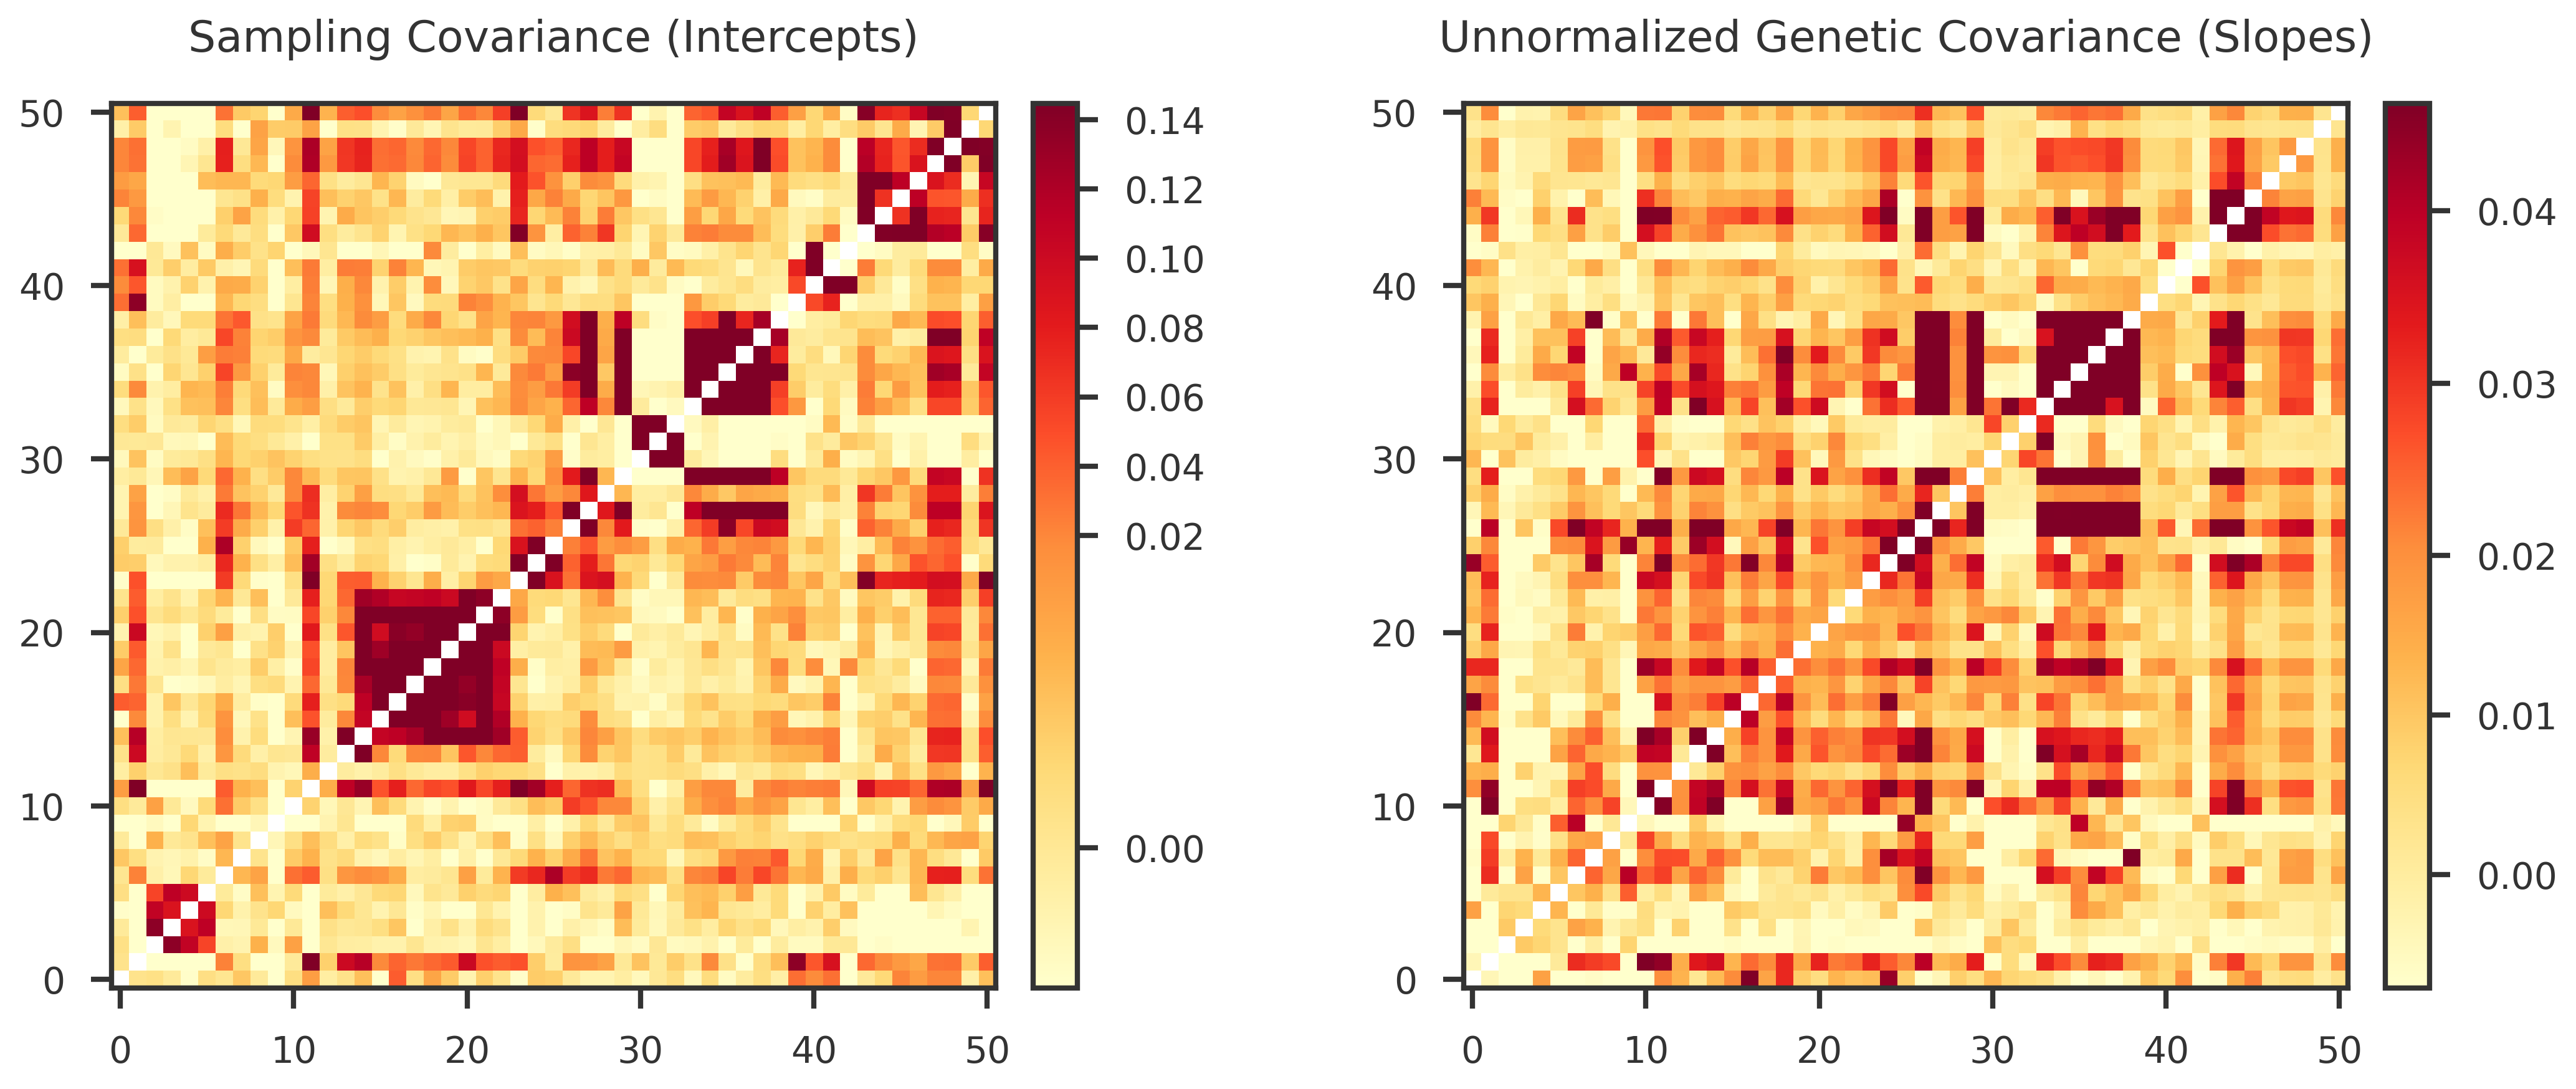

|Sampling Covariance| ∈ [0.00,0.05)
	n =  1076
	ρ = +0.134
	median|rg| = 0.198
	95th|rg| = 0.572
	frac_sig = 0.556
|Sampling Covariance| ∈ [0.05,0.10)
	n =    86
	ρ = +0.006
	median|rg| = 0.515
	95th|rg| = 0.854
	frac_sig = 0.977
|Sampling Covariance| ∈ [0.10,0.20)
	n =    70
	ρ = +0.088
	median|rg| = 0.538
	95th|rg| = 0.850
	frac_sig = 0.943
|Sampling Covariance| ∈ [0.20,0.40)
	n =    31
	ρ = +0.375
	median|rg| = 0.801
	95th|rg| = 1.202
	frac_sig = 1.000
|Sampling Covariance| ∈ [0.40,2.01)
	n =    12
	ρ = -0.378
	median|rg| = 0.902
	95th|rg| = 1.138
	frac_sig = 0.833


{'spearman': 0.30867082856852446,
 'pearson': 0.38997333853631033,
 'mantel_p': 9.999000099990002e-05,
 'x': array([0.001368  , 0.00216529, 0.0007015 , ..., 0.14691438, 0.14256507,
        0.00458009]),
 'y': array([-0.0037, -0.0076, -0.0311, ...,  0.0032,  0.014 ,  0.0025])}

In [7]:
Z = load_zscore(Path(data_root) / "pgc_v1.2/zscore_v1_2.csv")
trait_names = list(Z.index)

common_trait_names = sorted(
    trait_names,
    key=lambda trait: traits_meta[trait]['group']
)

S_51, G_51, R_51, R_p_51, S_se_51, G_se_51, R_se_51 = [
    df.loc[common_trait_names, common_trait_names]
    for df in (S, G, R, R_p, S_se, G_se, R_se)
]

make_heatmap_figure(
    S_51, G_51, 
    title_A="Sampling Covariance (Intercepts)", 
    title_B="Unnormalized Genetic Covariance (Slopes)")
offdiag_check(S_51, G_51, R_51, R_p_51)